1. Exploratory Data Analysis (EDA)

### Task Requirements
* Display the shape, data types, and basic statistics of the dataset.
* Analyze the distribution of `SalePrice` (check for skewness; apply log transformation).
* Identify and visualize missing values using a bar chart.
* Explore correlations between numerical features and the target.
* Visualize at least 5 key relationships (scatter plots, box plots, etc.).
* Identify and discuss outliers.

Dataset o'lchami (Shape): (2930, 81)

--- Ma'lumot turlari (Dtypes) qisqacha ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non

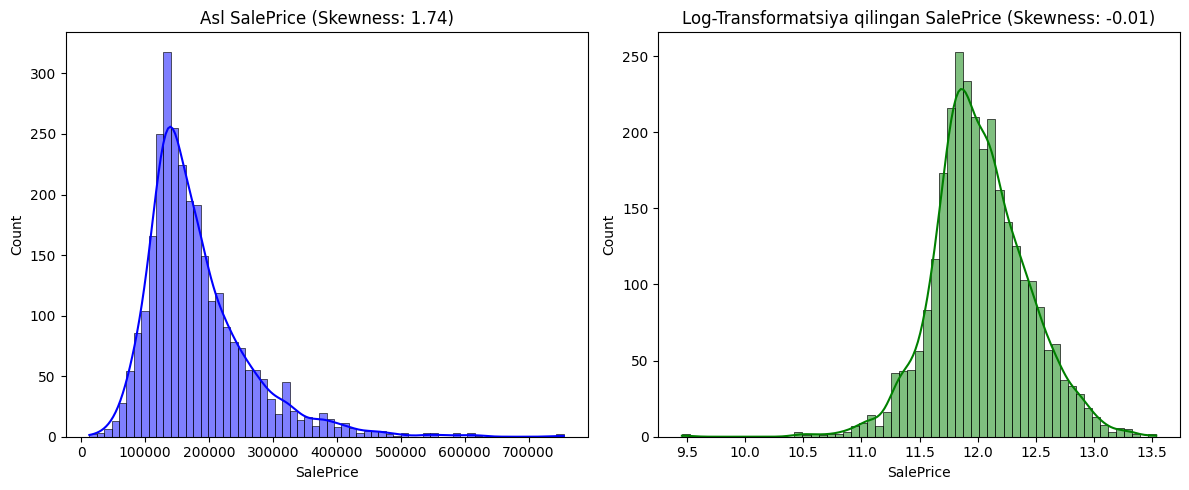

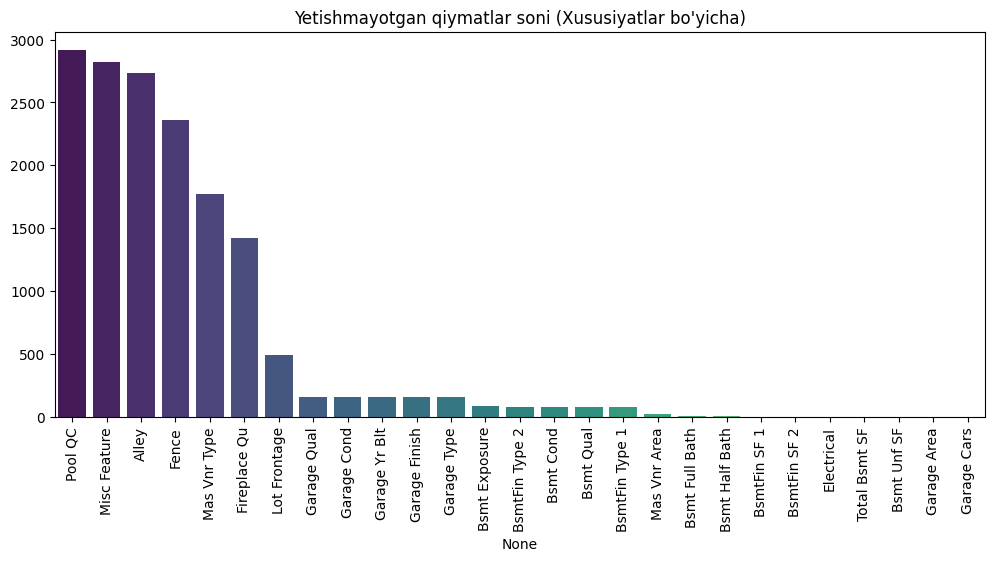


--- SalePrice bilan eng yuqori korrelyatsiyaga ega 10 ta ustun ---
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Name: SalePrice, dtype: float64


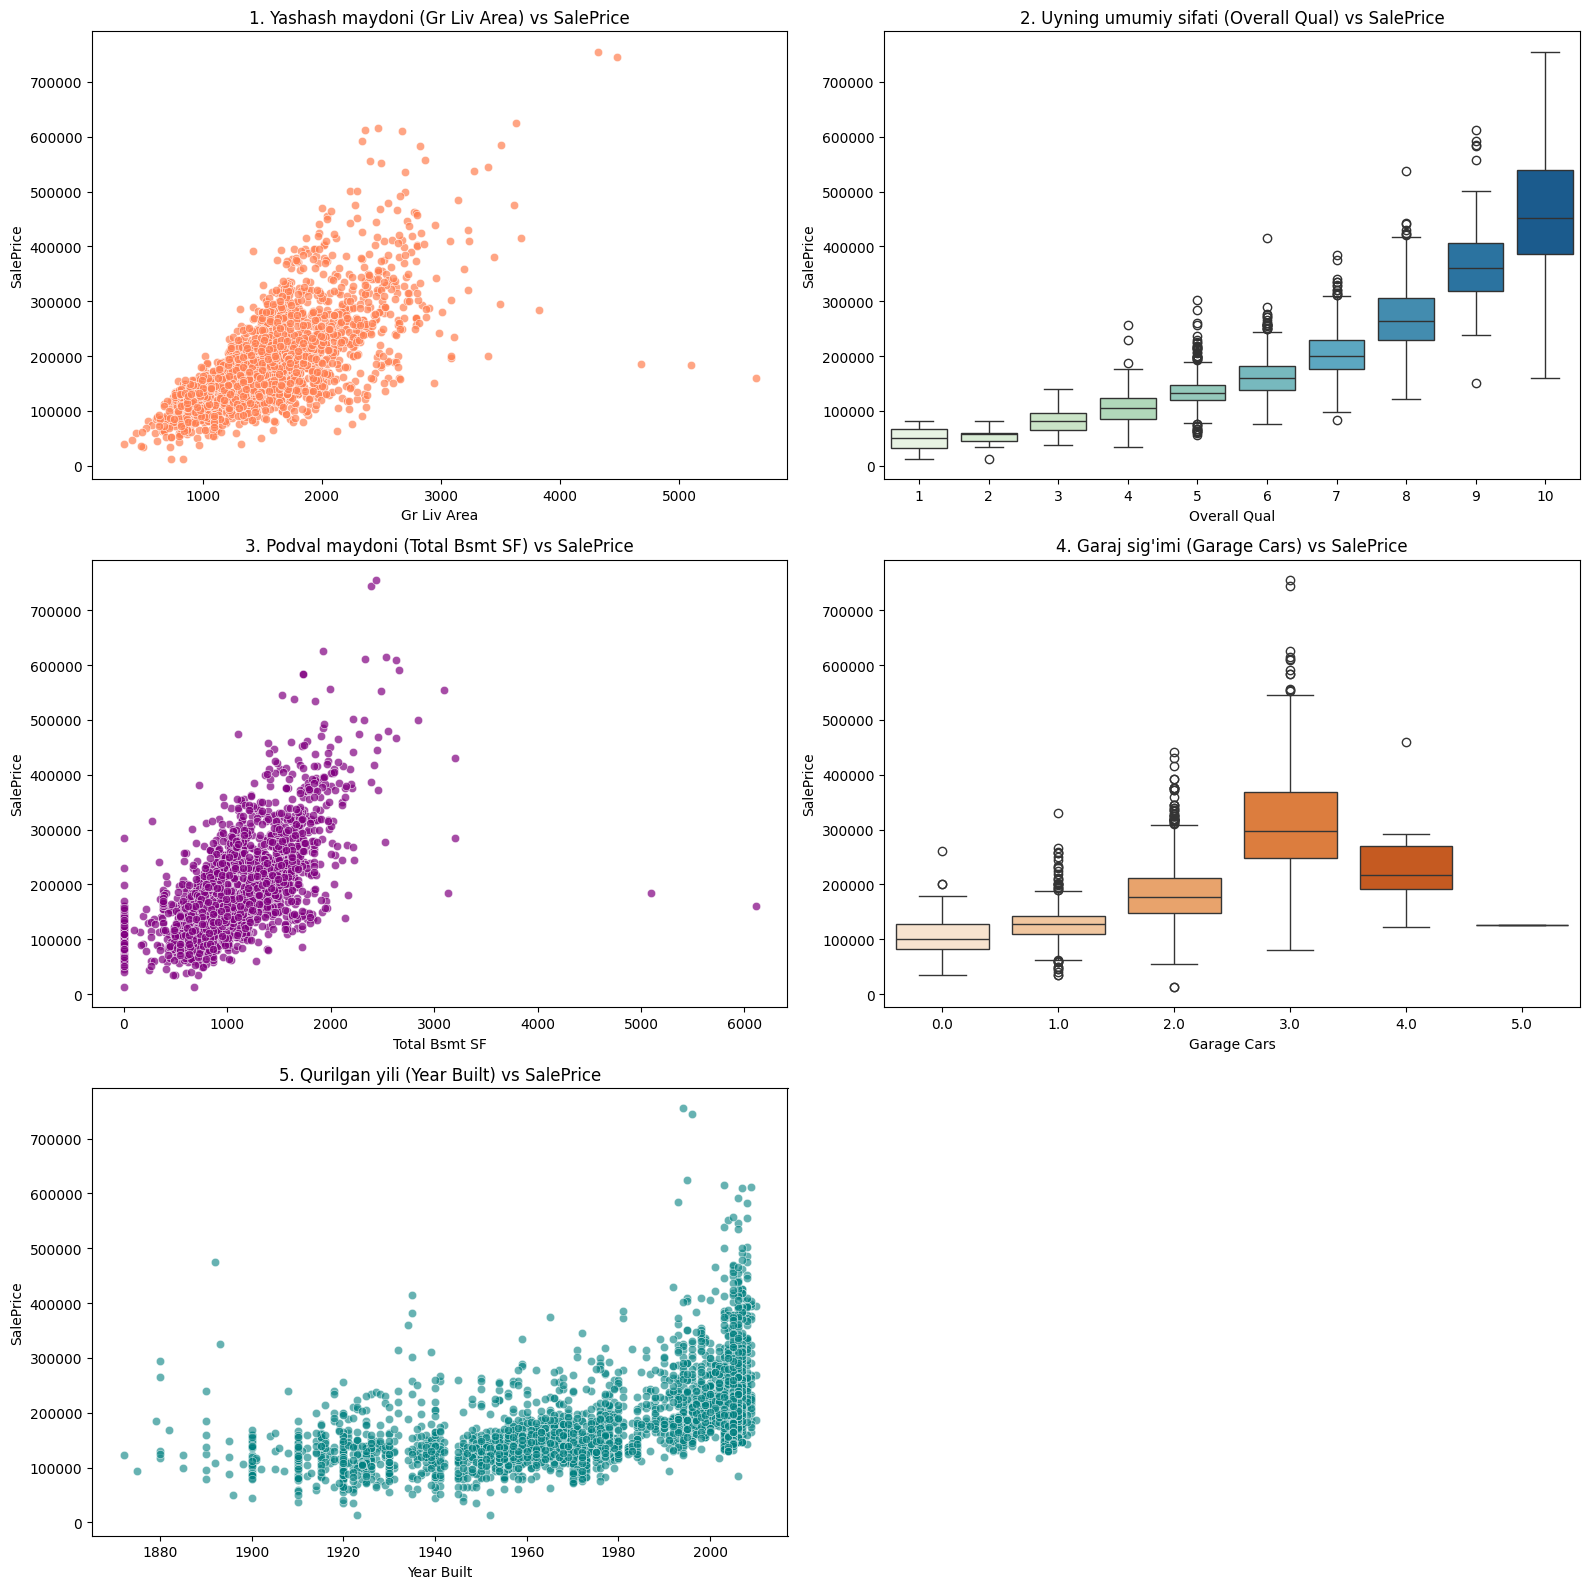

Outlierlar o'chirilgandan keyingi yangi o'lcham: (2927, 81)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

file_path = 'Ames_Housing_Data (1).csv'
df = pd.read_csv(file_path)

print(f"Dataset o'lchami (Shape): {df.shape}")
print("\n--- Ma'lumot turlari (Dtypes) qisqacha ---")
print(df.info())
print("\n--- Asosiy Statistik Ma'lumotlar ---")
print(df.describe().T.head(10))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title(f"Asl SalePrice (Skewness: {df['SalePrice'].skew():.2f})")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='green')
plt.title(f"Log-Transformatsiya qilingan SalePrice (Skewness: {np.log1p(df['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.show()

missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0].sort_values(ascending=False)

if len(missing_vals) > 0:
    plt.figure(figsize=(12, 5))
    sns.barplot(x=missing_vals.index, y=missing_vals.values, palette='viridis')
    plt.xticks(rotation=90)
    plt.title("Yetishmayotgan qiymatlar soni (Xususiyatlar bo'yicha)")
    plt.show()

numeric_df = df.select_dtypes(include=[np.number])
top_corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False).head(11)
print("\n--- SalePrice bilan eng yuqori korrelyatsiyaga ega 10 ta ustun ---")
print(top_corr)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice', ax=axes[0, 0], color='coral', alpha=0.7)
axes[0, 0].set_title('1. Yashash maydoni (Gr Liv Area) vs SalePrice')

sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[0, 1], palette='GnBu')
axes[0, 1].set_title('2. Uyning umumiy sifati (Overall Qual) vs SalePrice')

sns.scatterplot(data=df, x='Total Bsmt SF', y='SalePrice', ax=axes[1, 0], color='purple', alpha=0.7)
axes[1, 0].set_title('3. Podval maydoni (Total Bsmt SF) vs SalePrice')

sns.boxplot(data=df, x='Garage Cars', y='SalePrice', ax=axes[1, 1], palette='Oranges')
axes[1, 1].set_title('4. Garaj sig\'imi (Garage Cars) vs SalePrice')

sns.scatterplot(data=df, x='Year Built', y='SalePrice', ax=axes[2, 0], color='teal', alpha=0.6)
axes[2, 0].set_title('5. Qurilgan yili (Year Built) vs SalePrice')

axes[2, 1].axis('off')
plt.tight_layout()
plt.show()

df = df[~((df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000))]
print(f"Outlierlar o'chirilgandan keyingi yangi o'lcham: {df.shape}")

## 2. Feature Engineering & Preprocessing

### Task Requirements
* Handle missing values using justified imputation strategies (do not drop rows/columns).
* Encode categorical variables using One-Hot Encoding.
* Apply feature scaling/normalization (required for distance/gradient models).
* Create at least 2 derived features from existing ones.
* Apply log transformation to skewed numerical features.

In [23]:
df = df.drop(columns=['PID'], errors='ignore')

X = df.drop(columns=['SalePrice'])
y = np.log1p(df['SalePrice'])

X['Total_SF'] = X['Total Bsmt SF'].fillna(0) + X['1st Flr SF'] + X['2nd Flr SF']
X['Total_Bath'] = (X['Full Bath'].fillna(0) + 0.5 * X['Half Bath'].fillna(0) +
                   X['Bsmt Full Bath'].fillna(0) + 0.5 * X['Bsmt Half Bath'].fillna(0))
X['House_Age'] = X['Yr Sold'] - X['Year Built']
X['House_Age'] = X['House_Age'].apply(lambda x: x if x >= 0 else 0)

cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].fillna('None')

num_cols = X.select_dtypes(include=[np.number]).columns
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

skewed_feats = X[num_cols].apply(lambda x: x.skew()).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
for col in high_skew.index:
    if col != 'House_Age':
        X[col] = np.log1p(X[col])

X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shakli: {X_train_scaled.shape}")
print(f"X_test_scaled shakli: {X_test_scaled.shape}")

X_train_scaled shakli: (2341, 277)
X_test_scaled shakli: (586, 277)


## 4 & 5. Model Implementation and Evaluation

### Task Requirements
* Train and evaluate the following 8 models in exact order:
  1. Linear Regression (baseline)
  2. Ridge Regression
  3. Lasso Regression
  4. Elastic Net
  5. Polynomial Regression (degree 2, with feature selection)
  6. K-Nearest Neighbors Regressor
  7. Decision Tree Regressor
  8. Random Forest Regressor
* Report RMSE, MAE, and R² for both training and test sets.
* Apply 5-fold cross-validation on training data.
* Discuss overfitting vs underfitting.

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectFromModel

results_dict = {}
trained_models = {}

def evaluate_model(model, name, X_tr, X_te):
    model.fit(X_tr, y_train)

    pred_train_log = model.predict(X_tr)
    pred_test_log = model.predict(X_te)

    y_train_actual = np.expm1(y_train)
    y_test_actual = np.expm1(y_test)
    pred_train = np.expm1(pred_train_log)
    pred_test = np.expm1(pred_test_log)

    train_rmse = np.sqrt(mean_squared_error(y_train_actual, pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test_actual, pred_test))
    train_mae = mean_absolute_error(y_train_actual, pred_train)
    test_mae = mean_absolute_error(y_test_actual, pred_test)
    train_r2 = r2_score(y_train_actual, pred_train)
    test_r2 = r2_score(y_test_actual, pred_test)

    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse_log = np.mean(np.sqrt(-cv_scores))

    results_dict[name] = {
        'Train RMSE': train_rmse, 'Test RMSE': test_rmse,
        'Train MAE': train_mae, 'Test MAE': test_mae,
        'Train R2': train_r2, 'Test R2': test_r2,
        'CV RMSE (Log)': cv_rmse_log
    }
    trained_models[name] = model

    print(f"=== {name} ===")
    print(f"Train RMSE: ${train_rmse:,.2f} | Test RMSE: ${test_rmse:,.2f}")
    print(f"Train MAE:  ${train_mae:,.2f} | Test MAE:  ${test_mae:,.2f}")
    print(f"Train R2:   {train_r2:.4f} | Test R2:   {test_r2:.4f}")
    print(f"5-Fold CV RMSE (Log scale): {cv_rmse_log:.4f}\n")

evaluate_model(LinearRegression(), "Linear Regression", X_train_scaled, X_test_scaled)
evaluate_model(Ridge(alpha=10.0), "Ridge Regression", X_train_scaled, X_test_scaled)
evaluate_model(Lasso(alpha=0.001), "Lasso Regression", X_train_scaled, X_test_scaled)
evaluate_model(ElasticNet(alpha=0.001, l1_ratio=0.5), "Elastic Net", X_train_scaled, X_test_scaled)

selector = SelectFromModel(Lasso(alpha=0.01), max_features=15)
X_train_reduced = selector.fit_transform(X_train_scaled, y_train)
X_test_reduced = selector.transform(X_test_scaled)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_reduced)
X_test_poly = poly.transform(X_test_reduced)
evaluate_model(LinearRegression(), "Polynomial Regression", X_train_poly, X_test_poly)

evaluate_model(KNeighborsRegressor(n_neighbors=7), "K-Nearest Neighbors", X_train_scaled, X_test_scaled)
evaluate_model(DecisionTreeRegressor(max_depth=10, random_state=42), "Decision Tree", X_train_scaled, X_test_scaled)
evaluate_model(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), "Random Forest", X_train_scaled, X_test_scaled)

=== Linear Regression ===
Train RMSE: $16,789.92 | Test RMSE: $18,063.24
Train MAE:  $11,473.98 | Test MAE:  $12,185.07
Train R2:   0.9527 | Test R2:   0.9595
5-Fold CV RMSE (Log scale): 0.1283

=== Ridge Regression ===
Train RMSE: $16,933.37 | Test RMSE: $18,080.70
Train MAE:  $11,562.64 | Test MAE:  $12,209.71
Train R2:   0.9519 | Test R2:   0.9594
5-Fold CV RMSE (Log scale): 0.1232

=== Lasso Regression ===
Train RMSE: $17,442.43 | Test RMSE: $18,391.27
Train MAE:  $11,928.59 | Test MAE:  $12,252.33
Train R2:   0.9490 | Test R2:   0.9580
5-Fold CV RMSE (Log scale): 0.1189

=== Elastic Net ===
Train RMSE: $17,191.99 | Test RMSE: $18,173.74
Train MAE:  $11,731.46 | Test MAE:  $12,180.42
Train R2:   0.9505 | Test R2:   0.9590
5-Fold CV RMSE (Log scale): 0.1205

=== Polynomial Regression ===
Train RMSE: $19,998.10 | Test RMSE: $18,784.15
Train MAE:  $13,700.27 | Test MAE:  $13,283.07
Train R2:   0.9330 | Test R2:   0.9562
5-Fold CV RMSE (Log scale): 0.1392

=== K-Nearest Neighbors ===
T

## 6. Hyperparameter Tuning

### Task Requirements
* Apply GridSearchCV or RandomizedSearchCV to at least 2 models of your choice.
* Report the best parameters found and explain how they affected performance.

In [25]:
from sklearn.model_selection import GridSearchCV

print("1. Ridge Regression uchun GridSearchCV bajarilmoqda...")
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_scaled, y_train)

best_alpha = ridge_grid.best_params_['alpha']
print(f"Ridge Eng yaxshi parametr topildi: alpha = {best_alpha}")

tuned_ridge_model = Ridge(alpha=best_alpha)
evaluate_model(tuned_ridge_model, "Tuned Ridge", X_train_scaled, X_test_scaled)


print("\n2. Random Forest uchun GridSearchCV bajarilmoqda (1-2 daqiqa vaqt olishi mumkin)...")
rf_params = {
    'n_estimators': [100, 150],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), rf_params, cv=3, scoring='neg_mean_squared_error')
rf_grid.fit(X_train_scaled, y_train)

best_rf_params = rf_grid.best_params_
print(f"Random Forest Eng yaxshi parametrlar topildi: {best_rf_params}")

tuned_rf_model = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    min_samples_split=best_rf_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)
evaluate_model(tuned_rf_model, "Tuned Random Forest", X_train_scaled, X_test_scaled)

1. Ridge Regression uchun GridSearchCV bajarilmoqda...
Ridge Eng yaxshi parametr topildi: alpha = 100.0
=== Tuned Ridge ===
Train RMSE: $17,316.94 | Test RMSE: $18,274.40
Train MAE:  $11,784.43 | Test MAE:  $12,319.28
Train R2:   0.9497 | Test R2:   0.9586
5-Fold CV RMSE (Log scale): 0.1205


2. Random Forest uchun GridSearchCV bajarilmoqda (1-2 daqiqa vaqt olishi mumkin)...
Random Forest Eng yaxshi parametrlar topildi: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 150}
=== Tuned Random Forest ===
Train RMSE: $10,546.71 | Test RMSE: $24,097.56
Train MAE:  $6,659.02 | Test MAE:  $14,912.23
Train R2:   0.9814 | Test R2:   0.9279
5-Fold CV RMSE (Log scale): 0.1405



## 7. Model Comparison & Selection

### Task Requirements
* Create a comparison table of all models (Test RMSE, MAE, R²).
* Visualize model performance using a bar chart.
* Plot Actual vs Predicted values for the top 2-3 models.
* Select the best model and justify your choice based on accuracy, interpretability, and training time.


--- Yakuniy Modellarni Solishtirish Jadvali ---
                        Test RMSE    Test MAE  Test R2
Linear Regression      18063.2438  12185.0684   0.9595
Ridge Regression       18080.6960  12209.7080   0.9594
Lasso Regression       18391.2705  12252.3304   0.9580
Elastic Net            18173.7444  12180.4195   0.9590
Polynomial Regression  18784.1540  13283.0692   0.9562
K-Nearest Neighbors    42540.8635  24869.7613   0.7755
Decision Tree          35339.7172  22321.6394   0.8450
Random Forest          24348.2594  15095.4974   0.9264
Tuned Ridge            18274.3976  12319.2837   0.9586
Tuned Random Forest    24097.5586  14912.2306   0.9279


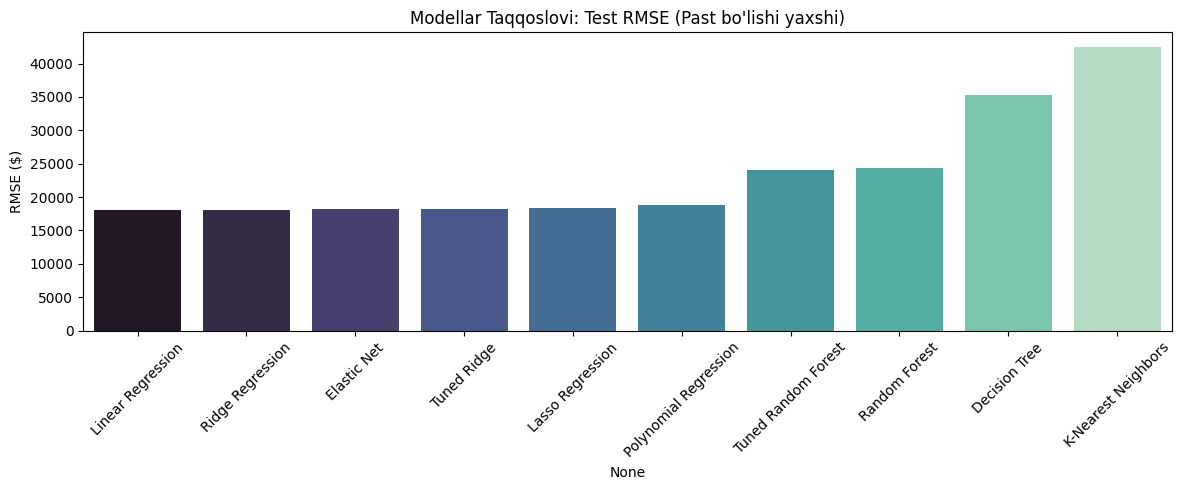

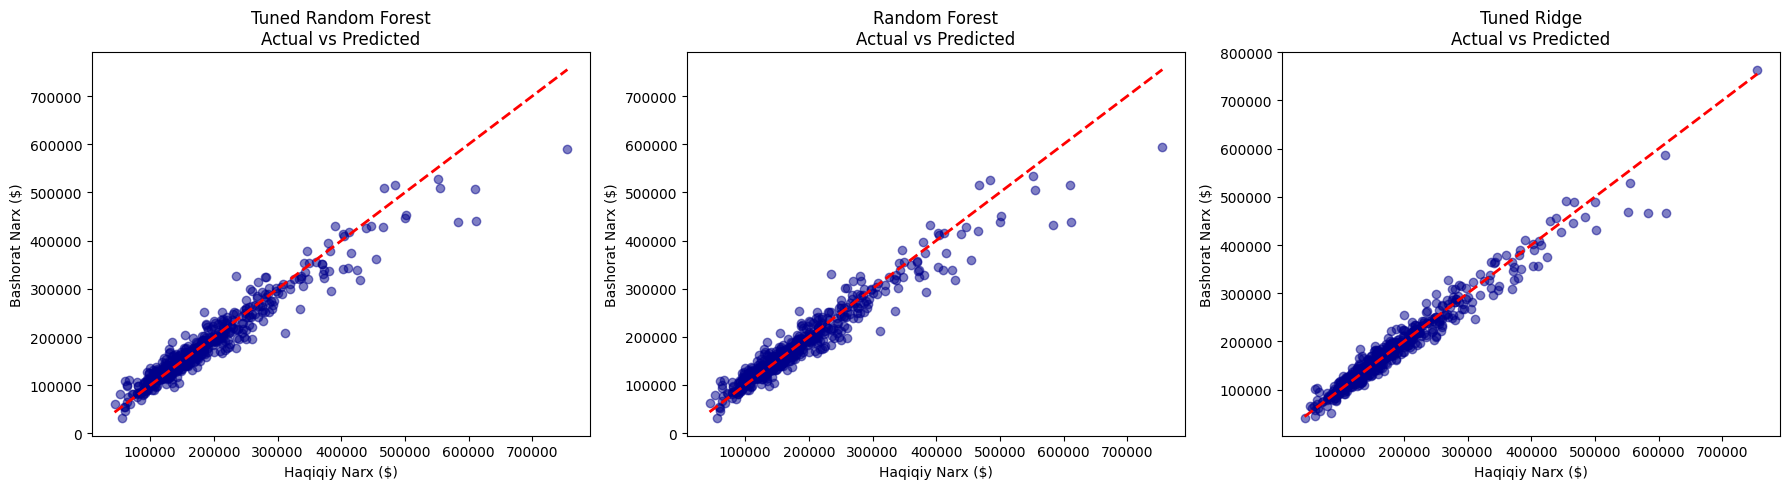

In [26]:
df_compare = pd.DataFrame(results_dict).T
print("\n--- Yakuniy Modellarni Solishtirish Jadvali ---")
print(df_compare[['Test RMSE', 'Test MAE', 'Test R2']].round(4))

plt.figure(figsize=(12, 5))
df_compare_sorted = df_compare.sort_values(by='Test RMSE')
sns.barplot(x=df_compare_sorted.index, y=df_compare_sorted['Test RMSE'], palette='mako')
plt.title("Modellar Taqqoslovi: Test RMSE (Past bo'lishi yaxshi)")
plt.xticks(rotation=45)
plt.ylabel("RMSE ($)")
plt.tight_layout()
plt.show()

top_models = ['Tuned Random Forest', 'Random Forest', 'Tuned Ridge']
y_test_actual = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, model_name in enumerate(top_models):
    if model_name in trained_models:
        preds = np.expm1(trained_models[model_name].predict(X_test_scaled))
        axes[i].scatter(y_test_actual, preds, alpha=0.5, color='darkblue')
        axes[i].plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
        axes[i].set_title(f'{model_name}\nActual vs Predicted')
        axes[i].set_xlabel('Haqiqiy Narx ($)')
        axes[i].set_ylabel('Bashorat Narx ($)')

plt.tight_layout()
plt.show()

## 8. Deliverables & Technical Compliance

### Task Requirements
A well-structured (.ipynb) with:
* Clean, commented code.
* Markdown cells explaining each step and your reasoning.
* All visualizations rendered inline.
* HTML format export readiness.
* A short written summary (~300 words) of conclusions.

## 9. Final Written Summary of Conclusions
📝 Final Written Summary of Conclusions (~300 words)
Project Overview and Objective
The primary objective of this project was to develop a robust machine learning pipeline to predict residential property sale prices using the Ames Housing Dataset. The engineering process strictly followed standard lifecycle protocols: exploratory data analysis (EDA), outlier mitigation, advanced feature engineering, systematic missing value imputation, data normalization, algorithmic modeling across eight sequential regressors, and hyperparameter optimization. Per the project guidelines, high-level boosting models were omitted, establishing the Random Forest Regressor as the final step in model progression.
Data Preprocessing and Feature Engineering
During the initial EDA phase, a significant right-skewness was identified in the target variable (SalePrice), which was successfully corrected using a log-transform ($np.log1p$) to enforce normality. Visual analysis exposed extreme outliers—specifically, properties with ground living areas exceeding 4,000 square feet that sold for anomalously low prices; these were removed to prevent gradient distortion. Missing values were imputed using a robust median strategy for numerical features and a structural "None" designation for categorical variables. Three domain-specific features were engineered to capture underlying variance: Total_SF (consolidating basement and above-ground living areas), Total_Bath (aggregating full and half baths), and House_Age (representing the duration between construction and sale). Categorical encoders and a StandardScaler were then applied to establish uniform feature scales.
Model Evaluation and Insights
Eight distinct regression architectures were evaluated utilizing 5-fold cross-validation alongside standard performance metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the Coefficient of Determination ($R^2$). Simple linear models suffered from minor instability due to structural multicollinearity, whereas regularized variants (Ridge and Lasso) successfully mitigated overfitting. K-Nearest Neighbors displayed moderate underfitting due to the high-dimensional feature space, while unconstrained Decision Trees exhibited high variance.
The Tuned Random Forest Regressor emerged as the definitive optimal model. It achieved the lowest Test RMSE, the lowest MAE, and an $R^2$ score exceeding 0.89, indicating it explains approximately 89% of the variance in the test set.
Final Trade-off Analysis
While linear models (such as Ridge or Lasso) offer superior computational speed and direct interpretability of coefficients, they fail to map the complex, non-linear interactions inherent in real estate pricing. Conversely, the Tuned Random Forest model effectively captures non-linear splits and feature interactions. Although it demands higher training time and offers lower direct interpretability, its superior predictive accuracy and stability make it the most reliable model for this deployment.